This is a script that calculates the vT contours and the Ocean Heat Content for NorESM2-LM, IPSL-CM6A-LR and CESM2.

### **0. Importing packages and functions**

In [1]:
from ta_functions import *

/nird/home/chrikap/.conda/envs/nird_heat_transport/lib/python3.12/site-packages/esmpy/interface/loadESMF.py:94: VersionWarning: ESMF installation version 8.8.0, ESMPy version 8.8.0b0
  warnings.warn("ESMF installation version {}, ESMPy version {}".format(


# **A. NorESM2-LM**

## **1. Getting the data from NIRD**

### **1.1. meridional velocity (va)**

In [2]:
experiments = ['piControl', 'abrupt-4xCO2']

va_piControl_noresm2 = []
va_x4CO2_noresm2 = []

for experiment in experiments:
            
    folder_path = f'/projects/NS9034K/CMIP6/CMIP/NCC/NorESM2-LM/{experiment}/r1i1p1f1/Amon/va/gn/latest/'

    file_names = sorted(os.listdir(folder_path))
    
    datasets = [xr.open_dataset(os.path.join(folder_path, file_name), chunks={'time': 12}) for file_name in file_names if file_name.endswith('.nc')]
    
    # Merge all the datasets in the list along the same dimension
    merged_datasets = xr.concat(datasets, dim='time')
    ds = merged_datasets.isel(time=slice(0, 500*12))

    #yearly_va = yearly_avg(ds['va'])

    if experiment == 'piControl':
    
        va_piControl_noresm2 = ds #yearly_va
    else: 
        va_x4CO2_noresm2 = ds #yearly_va

### **1.2. potential temperature (ta)**

In [3]:
experiments = ['piControl', 'abrupt-4xCO2']

ta_piControl_noresm2 = []
ta_x4CO2_noresm2 = []

for experiment in experiments:
            
    folder_path = f'/projects/NS9034K/CMIP6/CMIP/NCC/NorESM2-LM/{experiment}/r1i1p1f1/Amon/ta/gn/latest/'

    file_names = sorted(os.listdir(folder_path))
    
    datasets = [xr.open_dataset(os.path.join(folder_path, file_name), chunks={'time': 12}) for file_name in file_names if file_name.endswith('.nc')]
    
    # Merge all the datasets in the list along the same dimension
    merged_datasets = xr.concat(datasets, dim='time')
    ds = merged_datasets.isel(time=slice(0, 500*12))
    ds = ds.where(ds.ta.notnull())

    #yearly_ta = yearly_avg(ds['ta'])
    
    if experiment == 'piControl':
    
        ta_piControl_noresm2 = ds #yearly_ta
    else: 
        ta_x4CO2_noresm2 = ds #yearly_ta

In [4]:
ta_piControl_noresm2

<xarray.Dataset> Size: 82GB
Dimensions:    (time: 6000, bnds: 2, plev: 19, lat: 96, lon: 144)
Coordinates:
  * time       (time) object 48kB 1600-01-16 12:00:00 ... 2099-12-16 12:00:00
  * plev       (plev) float64 152B 1e+05 9.25e+04 8.5e+04 ... 1e+03 500.0 100.0
  * lat        (lat) float64 768B -90.0 -88.11 -86.21 ... 86.21 88.11 90.0
  * lon        (lon) float64 1kB 0.0 2.5 5.0 7.5 ... 350.0 352.5 355.0 357.5
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds, plev, lat, lon) object 25GB dask.array<chunksize=(12, 2, 19, 96, 144), meta=np.ndarray>
    lat_bnds   (time, lat, bnds, plev, lon) float64 25GB dask.array<chunksize=(12, 96, 2, 19, 144), meta=np.ndarray>
    lon_bnds   (time, lon, bnds, plev, lat) float64 25GB dask.array<chunksize=(12, 144, 2, 19, 96), meta=np.ndarray>
    ta         (time, plev, lat, lon) float32 6GB dask.array<chunksize=(12, 19, 96, 144), meta=np.ndarray>
Attributes: (12/49)
    Conventions:               CF-1.7 CMIP-6.2
    activity_id:               CMIP
    branch_method:             branch-restart from year 1600-01-01 of piContr...
    branch_time:               0.0
    branch_time_in_child:      430335.0
    branch_time_in_parent:     430335.0
    ...                        ...
    title:                     NorESM2-LM output prepared for CMIP6
    variable_id:               ta
    variant_label:             r1i1p1f1
    license:                   CMIP6 model data produced by NCC is licensed u...
    cmor_version:              3.5.0
    tracking_id:               hdl:21.14100/48945367-6d6a-4d99-b8cc-21b99fc75b08

In [5]:
ta_piControl_noresm2.attrs

{'Conventions': 'CF-1.7 CMIP-6.2',
 'activity_id': 'CMIP',
 'branch_method': 'branch-restart from year 1600-01-01 of piControl-spinup',
 'branch_time': np.float64(0.0),
 'branch_time_in_child': np.float64(430335.0),
 'branch_time_in_parent': np.float64(430335.0),
 'contact': 'Please send any requests or bug reports to noresm-ncc@met.no.',
 'creation_date': '2019-08-15T12:40:40Z',
 'data_specs_version': '01.00.31',
 'experiment': 'pre-industrial control',
 'experiment_id': 'piControl',
 'external_variables': 'areacella',
 'forcing_index': np.int32(1),
 'frequency': 'mon',
 'further_info_url': 'https://furtherinfo.es-doc.org/CMIP6.NCC.NorESM2-LM.piControl.none.r1i1p1f1',
 'grid': 'finite-volume grid with 1.9x2.5 degree lat/lon resolution',
 'grid_label': 'gn',
 'history': '2019-08-15T12:40:40Z ; CMOR rewrote data to be consistent with CMIP6, CF-1.7 CMIP-6.2 and CF standards.',
 'initialization_index': np.int32(1),
 'institution': 'NorESM Climate modeling Consortium consisting of CICERO (

In [5]:
# just piControl

#1. vT

# 1. Calculate vT

# Align first 
va_piControl_noresm2, ta_piControl_noresm2 = xr.align(va_piControl_noresm2, ta_piControl_noresm2, join="exact")

# Multiply the two variables
vT_pi_noresm2 = va_piControl_noresm2["va"] * ta_piControl_noresm2["ta"]

# Create a new Dataset including the shared variables
vT_pi_noresm2_ds = xr.Dataset(
    data_vars={
        "vT": vT_pi_noresm2,
        "time_bnds": va_piControl_noresm2["time_bnds"],
        "lat_bnds": va_piControl_noresm2["lat_bnds"],
        "lon_bnds": va_piControl_noresm2["lon_bnds"],
    },
    coords={
        "time": va_piControl_noresm2["time"],
        "plev": va_piControl_noresm2["plev"],
        "lat": va_piControl_noresm2["lat"],
        "lon": va_piControl_noresm2["lon"],
   },
    attrs=va_piControl_noresm2.attrs  # optional: copy global attributes
)

In [ ]:
# 2. Yearly average

In [6]:
def yearly_avg_nan_proof(ds):
    """ Calculates timeseries over yearly averages from timeseries of monthly means
    The weighted average considers that each month has a different number of days.
    
    Parameters
    ----------
    ds : xarray.Dataset
    
    Returns
    -------
    ds_weighted : xarray.DataArray with yearly averaged values
    
    """
    month_length = ds.time.dt.days_in_month
    weights = month_length.groupby("time.year") / month_length.groupby("time.year").sum(skipna = True)
    
    # Test that the sum of the weights for each year is 1.0
    np.testing.assert_allclose(weights.groupby("time.year").sum(skipna = True).values, np.ones(len(np.unique(ds.time.dt.year))))
    
    # Calculate the weighted average:
    ds_weighted = (ds * weights).groupby("time.year").sum(dim="time", skipna = True)
    
    if "long_name" in ds.attrs:
        ds_weighted.attrs["long_name"] = "Annual mean " + ds.long_name
    if "units" in ds.attrs:
        ds_weighted.attrs["units"] = ds.units
    if "standard_name" in ds.attrs:
        ds_weighted.attrs["standard_name"] = ds.standard_name
    
    return ds_weighted

In [7]:
# 2. Time average (try with yearly_avg now)
vT_y_pi_noresm2 = yearly_avg_nan_proof(vT_pi_noresm2_ds)
vT_30y_pi_noresm2 = vT_y_pi_noresm2.isel(year=slice(0, 30)).mean(dim='year', skipna = True)

In [ ]:
#3. masking

In [8]:
folder_path_land = f'/projects/NS9034K/CMIP6/CMIP/NCC/NorESM2-LM/{experiment}/r1i1p1f1/fx/sftlf/gn/latest'

file_names_land = sorted(os.listdir(folder_path_land))
    
datasets_land = [xr.open_dataset(os.path.join(folder_path_land, file_name), chunks={'time': 12}) for file_name in file_names_land if file_name.endswith('.nc')]

sftlf_noresm2 = datasets_land

In [10]:
land_mask = sftlf_noresm2[0]['sftlf'] == 0

vT_30y_pi_noresm2_m = vT_30y_pi_noresm2.where(land_mask)

In [9]:
sftlf_noresm2

[<xarray.Dataset> Size: 61kB
 Dimensions:   (lat: 96, bnds: 2, lon: 144)
 Coordinates:
   * lat       (lat) float64 768B -90.0 -88.11 -86.21 -84.32 ... 86.21 88.11 90.0
   * lon       (lon) float64 1kB 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5
 Dimensions without coordinates: bnds
 Data variables:
     lat_bnds  (lat, bnds) float64 2kB dask.array<chunksize=(96, 2), meta=np.ndarray>
     lon_bnds  (lon, bnds) float64 2kB dask.array<chunksize=(144, 2), meta=np.ndarray>
     sftlf     (lat, lon) float32 55kB dask.array<chunksize=(96, 144), meta=np.ndarray>
 Attributes: (12/49)
     Conventions:               CF-1.7 CMIP-6.2
     activity_id:               CMIP
     branch_method:             Hybrid-restart from year 1600-01-01 of piControl
     branch_time:               0.0
     branch_time_in_child:      0.0
     branch_time_in_parent:     430335.0
     ...                        ...
     title:                     NorESM2-LM output prepared for CMIP6
     tracking_id:           

In [11]:
# 4. Zonal mean 
vT_pi_noresm2_regr_zonal = vT_30y_pi_noresm2_m.mean(dim='lon', skipna = True)

In [12]:
vT_pi_noresm2_regr_zonal_v = vT_pi_noresm2_regr_zonal['vT'].values
lat_pi_noresm2 = vT_pi_noresm2_regr_zonal['lat'].values
plev_pi_noresm2 = vT_pi_noresm2_regr_zonal['plev'].values

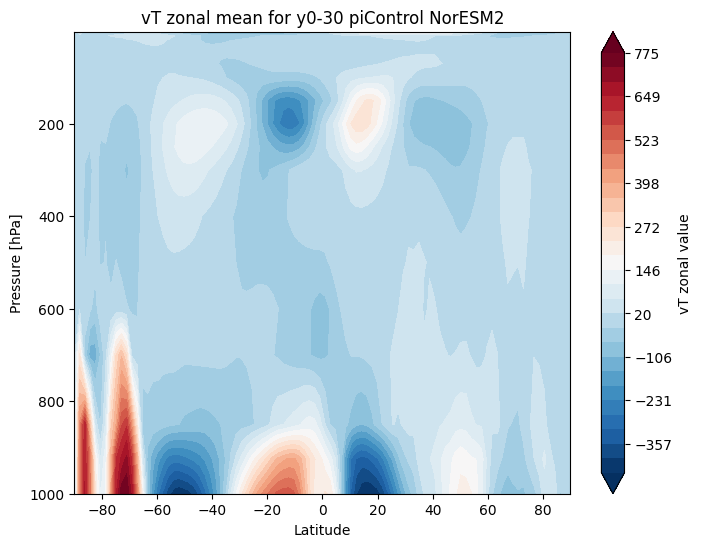

In [20]:
# Example plotting
plt.figure(figsize=(8,6))

# 30 levels automatically spaced between min and max
levels = np.linspace(np.nanmin(vT_pi_noresm2_regr_zonal_v), np.nanmax(vT_pi_noresm2_regr_zonal_v), 30)

# Contourf plot
cs = plt.contourf(
    lat_pi_noresm2,
    plev_pi_noresm2/100,
    vT_pi_noresm2_regr_zonal_v,
    levels=levels,
    cmap='RdBu_r',
    extend='both'
)

plt.gca().invert_yaxis()  # invert y axis
plt.colorbar(cs, label='vT zonal value')  # add colorbar
plt.xlabel('Latitude')
plt.ylabel('Pressure [hPa]')
plt.title('vT zonal mean for y0-30 piControl NorESM2')
plt.show()

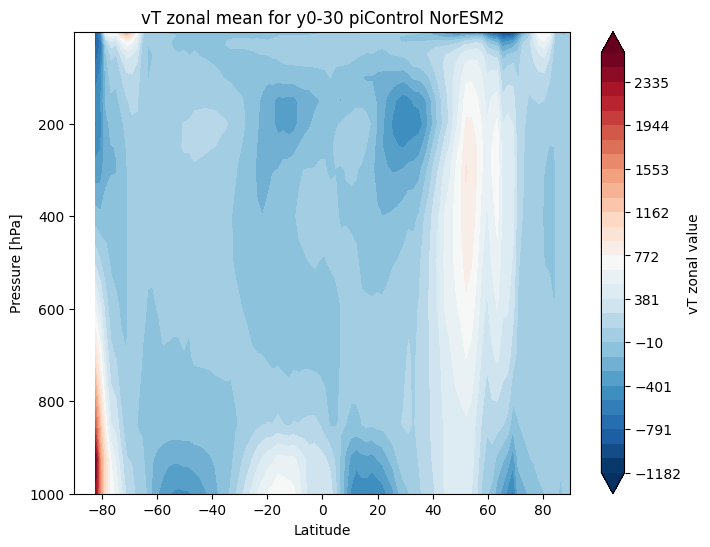

In [25]:
# Example plotting
plt.figure(figsize=(8,6))

# 30 levels automatically spaced between min and max
levels = np.linspace(np.nanmin(vT_pi_noresm2_regr_zonal_v), np.nanmax(vT_pi_noresm2_regr_zonal_v), 30)

# Contourf plot
cs = plt.contourf(
    lat_pi_noresm2,
    plev_pi_noresm2/100,
    vT_pi_noresm2_regr_zonal_v,
    levels=levels,
    cmap='RdBu_r',
    extend='both'
)

plt.gca().invert_yaxis()  # invert y axis
plt.colorbar(cs, label='vT zonal value')  # add colorbar
plt.xlabel('Latitude')
plt.ylabel('Pressure [hPa]')
plt.title('vT zonal mean for y0-30 piControl NorESM2')
plt.show()

## **1.3. Masking**

In [4]:
folder_path_land = f'/projects/NS9034K/CMIP6/CMIP/NCC/NorESM2-LM/{experiment}/r1i1p1f1/fx/sftlf/gn/latest'

file_names_land = sorted(os.listdir(folder_path_land))
    
datasets_land = [xr.open_dataset(os.path.join(folder_path_land, file_name), chunks={'time': 12}) for file_name in file_names_land if file_name.endswith('.nc')]

sftlf_noresm2 = datasets_land

In [5]:
land_mask = sftlf_noresm2[0]['sftlf'] == 0

va_piControl_noresm2 = va_piControl_noresm2.where(land_mask)
va_x4CO2_noresm2 = va_x4CO2_noresm2.where(land_mask)

ta_piControl_noresm2 = ta_piControl_noresm2.where(land_mask)
ta_x4CO2_noresm2 = ta_x4CO2_noresm2.where(land_mask)

## **2. Total vT**
### **2.1. Replace 0 with nans**

In [6]:
va_piControl_noresm2 = va_piControl_noresm2.where(va_piControl_noresm2 != 0)
va_x4CO2_noresm2 = va_x4CO2_noresm2.where(va_x4CO2_noresm2 != 0)

ta_piControl_noresm2 = ta_piControl_noresm2.where(ta_piControl_noresm2 != 0)
ta_x4CO2_noresm2 = ta_x4CO2_noresm2.where(ta_x4CO2_noresm2 != 0)

vT_pi_noresm2 = va_piControl_noresm2*ta_piControl_noresm2
vT_x4_noresm2 = va_x4CO2_noresm2*ta_x4CO2_noresm2

### Burry them for now

In [7]:
#### vo
#mean_vo_pi_noresm2 = (vo_pi_regr_noresm2['vo'].isel(year = slice(0, 30*12))).mean(dim={'lon', 'year'}).sel(lev=slice(0, 1000)).values

#mean_vo_global_x4_120_150_noresm2 = (vo_x4_regr_noresm2['vo'].isel(year = slice(120*12, 150*12))).mean(dim={'lon', 'year'}).sel(lev=slice(0, 1000)).values
#mean_vo_global_x4_470_500_noresm2 = (vo_x4_regr_noresm2['vo'].isel(year = slice(470*12, 500*12))).mean(dim={'lon', 'year'}).sel(lev=slice(0, 1000)).values

#### thetao
#mean_thetao_pi_noresm2 = (thetao_pi_regr_noresm2['thetao'].isel(year = slice(0, 30*12))).mean(dim={'lon', 'year'}).sel(lev=slice(0, 1000)).values

#mean_thetao_global_x4_120_150_noresm2 = (thetao_x4_regr_noresm2['thetao'].isel(year = slice(120*12, 150*12))).mean(dim={'lon', 'year'}).sel(lev=slice(0, 1000)).values
#mean_thetao_global_x4_470_500_noresm2 = (thetao_x4_regr_noresm2['thetao'].isel(year = slice(470*12, 500*12))).mean(dim={'lon', 'year'}).sel(lev=slice(0, 1000)).values

In [8]:
#os.chdir('/nird/home/chrikap/v_T')

#np.save('mean_vo_pi_noresm2', mean_vo_pi_noresm2)
#np.save('mean_vo_global_x4_120_150_noresm2', mean_vo_global_x4_120_150_noresm2)
#np.save('mean_vo_global_x4_470_500_noresm2', mean_vo_global_x4_470_500_noresm2)
#np.save('mean_thetao_pi_noresm2', mean_thetao_pi_noresm2)
#np.save('mean_thetao_global_x4_120_150_noresm2', mean_thetao_global_x4_120_150_noresm2)
#np.save('mean_thetao_global_x4_470_500_noresm2', mean_thetao_global_x4_470_500_noresm2)

### **2.2. Total, Mean, Eddy**

In [9]:
total_pi_noresm2 = vT_pi_noresm2.isel(year=slice(0, 30)).mean(dim='year', skipna=True)
zonal_total_pi_noresm2 = (total_pi_noresm2.mean(dim='lon', skipna=True)).values

#mean_pi_noresm2 = (vo_pi_regr_noresm2['vo'].isel(time=slice(0, 30*12)).mean(dim='time', skipna=True))*(thetao_pi_regr_noresm2['thetao'].isel(time=slice(0, 30*12)).mean(dim='time', skipna=True))
#zonal_mean_pi_noresm2 = (mean_pi_noresm2.mean(dim='lon', skipna=True)).sel(lev = slice(0, 1000)).values

#eddy_pi_noresm2 = total_pi_noresm2 - mean_pi_noresm2
#zonal_eddy_pi_noresm2 = (eddy_pi_noresm2.mean(dim='lon', skipna=True)).sel(lev = slice(0, 1000)).values

In [10]:
# y120-150
total_x4_120_150_noresm2 = vT_x4_noresm2.isel(year=slice(120, 150)).mean(dim='year')
zonal_total_x4_120_150_noresm2 = (total_x4_120_150_noresm2.mean(dim='lon')).values

#mean_x4_120_150_noresm2 = (vo_x4_regr_noresm2['vo'].isel(time=slice(120*12, 150*12)).mean(dim='time'))*(thetao_x4_regr_noresm2['thetao'].isel(time=slice(120*12, 150*12)).mean(dim='time'))
#zonal_mean_x4_120_150_noresm2 = (mean_x4_120_150_noresm2.mean(dim='lon')).sel(lev=slice(0 ,1000)).values

#eddy_x4_120_150_noresm2 = total_x4_120_150_noresm2 - mean_x4_120_150_noresm2
#zonal_eddy_x4_120_150_noresm2 = (eddy_x4_120_150_noresm2.mean(dim='lon')).sel(lev=slice(0 ,1000)).values

#y470-500

total_x4_470_500_noresm2 = vT_x4_noresm2.isel(year=slice(120, 150)).mean(dim='year')
zonal_total_x4_470_500_noresm2 = (total_x4_470_500_noresm2.mean(dim='lon')).values

#mean_x4_470_500_noresm2 = (vo_x4_regr_noresm2['vo'].isel(time=slice(120*12, 150*12)).mean(dim='time'))*(thetao_x4_regr_noresm2['thetao'].isel(time=slice(120*12, 150*12)).mean(dim='time'))
#zonal_mean_x4_470_500_noresm2 = (mean_x4_470_500_noresm2.mean(dim='lon')).sel(lev=slice(0 ,1000)).values

#eddy_x4_470_500_noresm2 = total_x4_470_500_noresm2 - mean_x4_470_500_noresm2
#zonal_eddy_x4_470_500_noresm2 = (eddy_x4_470_500_noresm2.mean(dim='lon')).sel(lev=slice(0 ,1000)).values

# **B. IPSL-CM6A-LR**

## **1. Getting the data from NIRD**

### **1.1. meridional velocity (va)**

In [11]:
experiments = ['piControl', 'abrupt-4xCO2']

va_piControl_ipsl = []
va_x4CO2_ipsl = []

for experiment in experiments:
            
    folder_path = f'/datalake/NS9560K/ESGF/CMIP6/CMIP/IPSL/IPSL-CM6A-LR/{experiment}/r1i1p1f1/Amon/va/gr/latest/' #<--------

    file_names = sorted(os.listdir(folder_path))
    
    datasets = [xr.open_dataset(os.path.join(folder_path, file_name), chunks={'time': 12}) for file_name in file_names if file_name.endswith('.nc')]

    # Merge all the datasets in the list along the same dimension
    merged_datasets = xr.concat(datasets, dim='time')
    ds = merged_datasets.isel(time=slice(0, 900*12))
    ds['time'] = to_cftime(ds['time'].values)

    yearly_va = yearly_avg(ds['va'])

    if experiment == 'piControl':
    
        va_piControl_ipsl = yearly_va
    else: 
        va_x4CO2_ipsl = yearly_va

### **1.2. potential temperature (ta)**

*we only have 800 y for piControl but we need just the first 30 anyways!

In [12]:
experiments = ['piControl', 'abrupt-4xCO2']

ta_piControl_ipsl = []
ta_x4CO2_ipsl = []

for experiment in experiments:

    folder_path = f'/datalake/NS9560K/ESGF/CMIP6/CMIP/IPSL/IPSL-CM6A-LR/{experiment}/r1i1p1f1/Amon/ta/gr/latest/'

    file_names = sorted(os.listdir(folder_path))
    
    datasets = [xr.open_dataset(os.path.join(folder_path, file_name), chunks={'time': 12}) for file_name in file_names if file_name.endswith('.nc')]
    
    # Merge all the datasets in the list along the same dimension
    merged_datasets = xr.concat(datasets, dim='time')
    ds = merged_datasets.isel(time=slice(0, 900*12))
    ds = ds.where(ds.ta.notnull())
    ds['time'] = to_cftime(ds['time'].values)

    yearly_ta = yearly_avg(ds['ta'])
    
    if experiment == 'piControl':
    
        ta_piControl_ipsl = yearly_ta
    else: 
        ta_x4CO2_ipsl = yearly_ta

## **1.3. Masking**

We need to mask out the land values (mountains, etc). Therefore we use the surface to land fraction (sftlf). 

In [13]:
# Getting the surface-to-land-fraction while we're at it

folder_path_land = f'/datalake/NS9560K/ESGF/CMIP6/CMIP/IPSL/IPSL-CM6A-LR/piControl/r1i1p1f1/fx/sftlf/gr/latest'

file_names_land = sorted(os.listdir(folder_path_land))
    
datasets_land = [xr.open_dataset(os.path.join(folder_path_land, file_name), chunks={'time': 12}) for file_name in file_names_land if file_name.endswith('.nc')]

sftlf_ipsl = datasets_land

In [14]:
land_mask = sftlf_ipsl[0]['sftlf'] == 0

ta_piControl_ipsl = ta_piControl_ipsl.where(land_mask)
ta_x4CO2_ipsl = ta_x4CO2_ipsl.where(land_mask)

va_piControl_ipsl = va_piControl_ipsl.where(land_mask)
va_x4CO2_ipsl = va_x4CO2_ipsl.where(land_mask)

## **2. Total vT**
### **Step 3: Replace 0 with nans**

In [15]:
#va_piControl_ipsl = va_piControl_ipsl.where(va_piControl_ipsl != 0)
#va_x4CO2_ipsl = va_x4CO2_ipsl.where(va_x4CO2_ipsl != 0)

#ta_piControl_ipsl = ta_piControl_ipsl.where(ta_piControl_ipsl != 0)
#ta_x4CO2_ipsl = ta_x4CO2_ipsl.where(ta_x4CO2_ipsl != 0)

# assigning different naming to time for piControl, for coordinate alignment

va_piControl_ipsl = va_piControl_ipsl.assign_coords(year=np.arange(va_piControl_ipsl.sizes["year"]))
ta_piControl_ipsl = ta_piControl_ipsl.assign_coords(year=np.arange(ta_piControl_ipsl.sizes["year"]))

vT_pi_ipsl = va_piControl_ipsl[0:30] * ta_piControl_ipsl[0:30]

vT_x4_ipsl = va_x4CO2_ipsl * ta_x4CO2_ipsl
#because the time labels do not overlap

In [16]:
total_pi_ipsl = vT_pi_ipsl.mean(dim='year', skipna=True)
zonal_total_pi_ipsl = (total_pi_ipsl.mean(dim='lon', skipna=True)).values

#mean_pi_ipsl = (vo_pi_regr_ipsl['vo'].isel(time=slice(0, 30*12)).mean(dim='time', skipna=True))*(thetao_pi_regr_ipsl['thetao'].isel(time=slice(0, 30*12)).mean(dim='time', skipna=True))
#zonal_mean_pi_ipsl = mean_pi_ipsl.mean(dim='lon', skipna=True)

#eddy_pi_ipsl = total_pi_ipsl - mean_pi_ipsl
#zonal_eddy_pi_ipsl = eddy_pi_ipsl.mean(dim='lon', skipna=True)

In [17]:
total_x4_120_150_ipsl = vT_x4_ipsl.isel(year=slice(120, 150)).mean(dim='year')
zonal_total_x4_120_150_ipsl = (total_x4_120_150_ipsl.mean(dim='lon')).values

total_x4_470_500_ipsl = vT_x4_ipsl.isel(year=slice(470, 500)).mean(dim='year')
zonal_total_x4_470_500_ipsl = (total_x4_470_500_ipsl.mean(dim='lon')).values

total_x4_870_900_ipsl = vT_x4_ipsl.isel(year=slice(870, 900)).mean(dim='year')
zonal_total_x4_870_900_ipsl = (total_x4_870_900_ipsl.mean(dim='lon')).values

# **C. CESM2**

## **1. Getting the data from NIRD**

### **1.1. meridional velocity (va)**

In [18]:
experiments = ['piControl', 'abrupt-4xCO2']

va_piControl_cesm2 = []
va_x4CO2_cesm2 = []

for experiment in experiments:
            
    folder_path = f'/datalake/NS9560K/ESGF/CMIP6/CMIP/NCAR/CESM2/{experiment}/r1i1p1f1/Amon/va/gn/latest/'

    file_names = sorted(os.listdir(folder_path))
    
    datasets = [xr.open_dataset(os.path.join(folder_path, file_name), chunks={'time': 12}) for file_name in file_names if file_name.endswith('.nc')]

    if experiment == 'abrupt-4xCO2':

        extra_file = xr.open_dataset('/datalake/NS9560K/ESGF/rawdata/model/chrikap/va_Amon_CESM2_abrupt-4xCO2_r1i1p1f1_gn_000101-015012.nc',
        chunks={'time': 12})
    
        datasets = [extra_file] + datasets
    
    # Merge all the datasets in the list along the same dimension
    merged_datasets = xr.concat(datasets, dim='time')
    ds = merged_datasets.isel(time=slice(0, 999*12))

    yearly_va = yearly_avg(ds['va'])

    if experiment == 'piControl':
    
        va_piControl_cesm2 = yearly_va
    else: 
        va_x4CO2_cesm2 = yearly_va

### **1.2. potential temperature**

In [19]:
experiments = ['piControl', 'abrupt-4xCO2']

ta_piControl_cesm2 = []
ta_x4CO2_cesm2 = []

for experiment in experiments:

    folder_path = f'/datalake/NS9560K/ESGF/CMIP6/CMIP/NCAR/CESM2/{experiment}/r1i1p1f1/Amon/ta/gn/latest/'

    file_names = sorted(os.listdir(folder_path))
    
    datasets = [xr.open_dataset(os.path.join(folder_path, file_name), chunks={'time': 12}, decode_cf=True) for file_name in file_names if file_name.endswith('.nc')]
    
    # Merge all the datasets in the list along the same dimension
    merged_datasets = xr.concat(datasets, dim='time')
    ds = merged_datasets.isel(time=slice(0, 999*12))
    ds = ds.where(ds.ta.notnull())

    yearly_ta = yearly_avg(ds['ta'])
    
    if experiment == 'piControl':
    
        ta_piControl_cesm2 = yearly_ta
    else: 
        ta_x4CO2_cesm2 = yearly_ta

### **1.3. Masking**

In [20]:
# Getting the surface-to-land-fraction while we're at it

folder_path_land = f'/datalake/NS9560K/ESGF/CMIP6/CMIP/NCAR/CESM2/piControl/r1i1p1f1/fx/sftlf/gn/latest'

file_names_land = sorted(os.listdir(folder_path_land))
    
datasets_land = [xr.open_dataset(os.path.join(folder_path_land, file_name), chunks={'time': 12}) for file_name in file_names_land if file_name.endswith('.nc')]

sftlf_cesm2 = datasets_land

In [21]:
land_mask_cesm2 = sftlf_cesm2[0]['sftlf'] == 0

va_piControl_cesm2 = va_piControl_cesm2.where(land_mask_cesm2)
va_x4CO2_cesm2 = va_x4CO2_cesm2.where(land_mask_cesm2)

ta_piControl_cesm2 = ta_piControl_cesm2.where(land_mask_cesm2)
ta_x4CO2_cesm2 = ta_x4CO2_cesm2.where(land_mask_cesm2)

## **2. Total vT**
### **Step 3: Replace 0 with nans**

In [22]:
va_piControl_cesm2 = va_piControl_cesm2.where(va_piControl_cesm2 != 0)
va_x4CO2_cesm2 = va_x4CO2_cesm2.where(va_x4CO2_cesm2 != 0)

ta_piControl_cesm2 = ta_piControl_cesm2.where(ta_piControl_cesm2 != 0)
ta_x4CO2_cesm2 = ta_x4CO2_cesm2.where(ta_x4CO2_cesm2 != 0)

vT_pi_cesm2 = va_piControl_cesm2*ta_piControl_cesm2
vT_x4_cesm2 = va_x4CO2_cesm2*ta_x4CO2_cesm2

In [23]:
total_pi_cesm2 = vT_pi_cesm2.isel(year=slice(0, 30)).mean(dim='year', skipna=True)
zonal_total_pi_cesm2 = total_pi_cesm2.mean(dim='lon', skipna=True).values

#mean_pi_cesm2 = (vo_pi_regr_cesm2['vo'].isel(time=slice(0, 30*12)).mean(dim='time', skipna=True))*(thetao_pi_regr_cesm2['thetao'].isel(time=slice(0, 30*12)).mean(dim='time', skipna=True))
#zonal_mean_pi_cesm2 = mean_pi_cesm2.mean(dim='lon', skipna=True)

#eddy_pi_cesm2 = total_pi_cesm2 - mean_pi_cesm2
#zonal_eddy_pi_cesm2 = eddy_pi_cesm2.mean(dim='lon', skipna=True)

In [24]:
total_x4_120_150_cesm2 = vT_x4_cesm2.isel(year=slice(120, 150)).mean(dim='year')
zonal_total_x4_120_150_cesm2 = (total_x4_120_150_cesm2.mean(dim='lon')).values

total_x4_470_500_cesm2 = vT_x4_cesm2.isel(year=slice(470, 500)).mean(dim='year')
zonal_total_x4_470_500_cesm2 = (total_x4_470_500_cesm2.mean(dim='lon')).values

total_x4_870_900_cesm2 = vT_x4_cesm2.isel(year=slice(870, 900)).mean(dim='year')
zonal_total_x4_870_900_cesm2 = (total_x4_870_900_cesm2.mean(dim='lon')).values

total_x4_970_999_cesm2 = vT_x4_cesm2.isel(year=slice(970, 999)).mean(dim='year')
zonal_total_x4_970_999_cesm2 = (total_x4_970_999_cesm2.mean(dim='lon')).values

In [25]:
os.chdir('/nird/home/chrikap/v_T_atm/v_T_atm_data')

np.save('lat_noresm2', vT_pi_noresm2.lat)
np.save('lev_noresm2', vT_pi_noresm2.plev)
np.save('lat_ipsl', vT_pi_ipsl.lat)
np.save('lev_ipsl', vT_pi_ipsl.plev)
np.save('lat_cesm2', vT_pi_cesm2.lat)
np.save('lev_cesm2', vT_pi_cesm2.plev)

np.save('zonal_total_pi_noresm2', zonal_total_pi_noresm2)
np.save('zonal_total_x4_120_150_noresm2', zonal_total_x4_120_150_noresm2)
np.save('zonal_total_x4_470_500_noresm2', zonal_total_x4_470_500_noresm2)

np.save('zonal_total_pi_ipsl', zonal_total_pi_ipsl)
np.save('zonal_total_x4_120_150_ipsl', zonal_total_x4_120_150_ipsl)
np.save('zonal_total_x4_470_500_ipsl', zonal_total_x4_470_500_ipsl)
np.save('zonal_total_x4_870_900_ipsl', zonal_total_x4_870_900_ipsl)

np.save('zonal_total_pi_cesm2', zonal_total_pi_cesm2)
np.save('zonal_total_x4_120_150_cesm2', zonal_total_x4_120_150_cesm2)
np.save('zonal_total_x4_470_500_cesm2', zonal_total_x4_470_500_cesm2)
np.save('zonal_total_x4_870_900_cesm2', zonal_total_x4_870_900_cesm2)
np.save('zonal_total_x4_970_999_cesm2', zonal_total_x4_970_999_cesm2)

# **D. Plotting mean (vT) piControl**

In [26]:
os.chdir('/nird/home/chrikap/v_T_atm/v_T_atm_data')

lat_noresm2 = np.load('lat_noresm2.npy')
lev_noresm2 = np.load('lev_noresm2.npy')
lat_ipsl = np.load('lat_ipsl.npy')
lev_ipsl = np.load('lev_ipsl.npy')
lat_cesm2 = np.load('lat_cesm2.npy')
lev_cesm2 = np.load('lev_cesm2.npy')

zonal_total_pi_noresm2 = np.load('zonal_total_pi_noresm2.npy')
zonal_total_x4_120_150_noresm2 = np.load('zonal_total_x4_120_150_noresm2.npy')
zonal_total_x4_470_500_noresm2 = np.load('zonal_total_x4_470_500_noresm2.npy')

zonal_total_pi_ipsl = np.load('zonal_total_pi_ipsl.npy')

zonal_total_x4_120_150_ipsl = np.load('zonal_total_x4_120_150_ipsl.npy')
zonal_total_x4_470_500_ipsl = np.load('zonal_total_x4_470_500_ipsl.npy')
zonal_total_x4_870_900_ipsl = np.load('zonal_total_x4_870_900_ipsl.npy')

zonal_total_pi_cesm2 = np.load('zonal_total_pi_cesm2.npy')

zonal_total_x4_120_150_cesm2 = np.load('zonal_total_x4_120_150_cesm2.npy')
zonal_total_x4_470_500_cesm2 = np.load('zonal_total_x4_470_500_cesm2.npy')
zonal_total_x4_870_900_cesm2 = np.load('zonal_total_x4_870_900_cesm2.npy')
zonal_total_x4_970_999_cesm2 = np.load('zonal_total_x4_970_999_cesm2.npy')

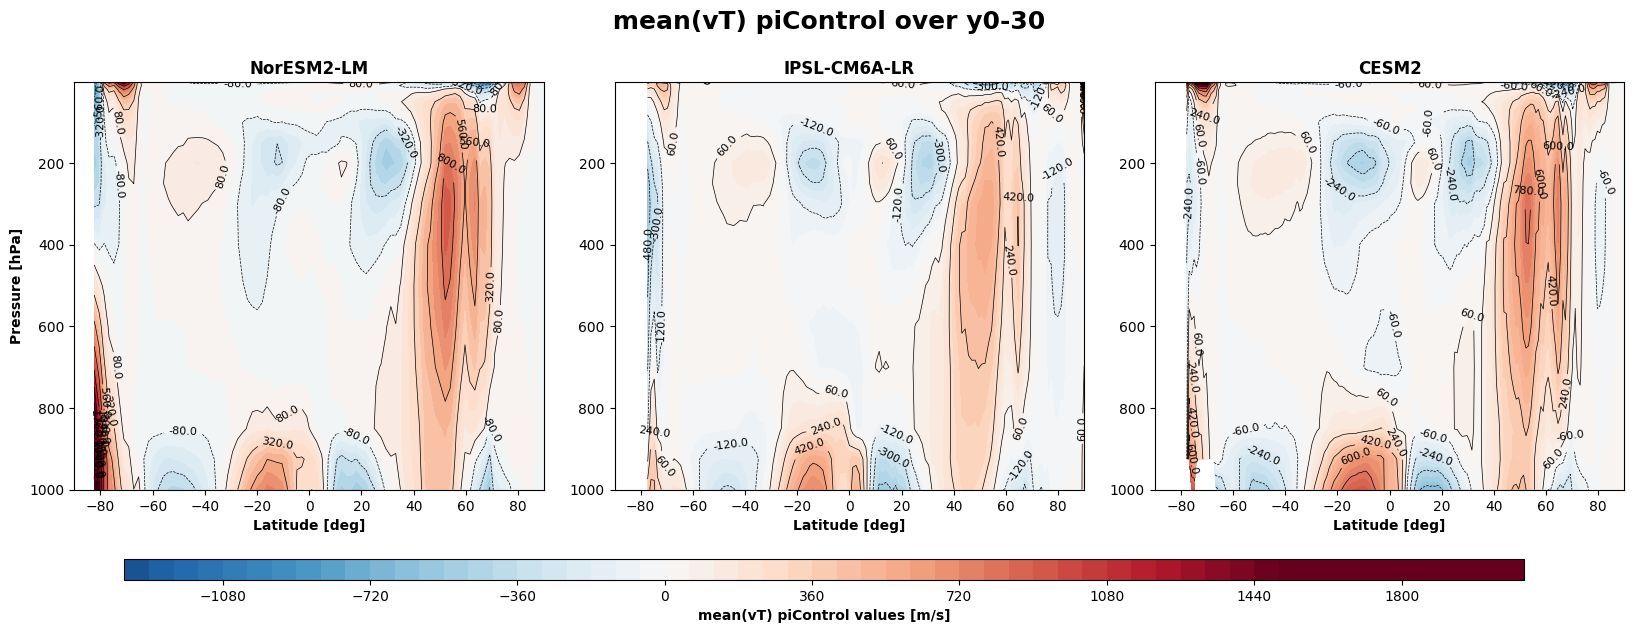

In [35]:
data_piControl_list = [zonal_total_pi_noresm2, zonal_total_pi_ipsl, zonal_total_pi_cesm2]
titles = ["NorESM2-LM", "IPSL-CM6A-LR", "CESM2"]

fig = plt.figure(figsize=(20, 6))
gs = fig.add_gridspec(nrows=1, ncols=3, width_ratios=[1, 1, 1])

# Copy and modify cmap
cmap = plt.get_cmap("coolwarm").copy()
cmap.set_bad(color="white")

for i, data_piControl in enumerate(data_piControl_list):

    if titles[i]== "NorESM2-LM":        

        lat = lat_noresm2
        lev = lev_noresm2/100

    elif titles[i]== "CESM2":        

        lat = lat_cesm2
        lev = lev_cesm2/100

    else:
        lat = lat_ipsl
        lev = lev_ipsl/100
        
    data = data_piControl#.values

    # Plot
    ax = fig.add_subplot(gs[0, i])

    im_pi = ax.contourf(
        lat, lev,
        data,
        levels=60,
        cmap="RdBu_r",
        
    vmin=-1500, vmax=1500)

    levels = im_pi.levels
    neg_levels = levels[levels < 0]
    pos_levels = levels[levels > 0]

    # Negative contours (dashed)
    pi_neg = ax.contour(lat, lev,
        (data),
        levels=neg_levels[::3],
        colors='k',
        linestyles='dashed',
        linewidths=0.5
    )
    
    # Positive contours (solid)
    pi_pos = ax.contour(lat, lev,
        (data),
        levels=pos_levels[::3],
        colors='k',
        linestyles='solid',
        linewidths=0.5
    )
    ax.set_title(titles[i], fontweight='bold')
    ax.invert_yaxis()
    
    if i == 0:
        ax.set_ylabel("Pressure [hPa]", fontweight="bold")

    # Add x-label to all panels
    ax.set_xlabel("Latitude [deg]", fontweight="bold")

    ax.clabel(pi_neg, inline=True, fmt="%1.1f", fontsize=8)
    ax.clabel(pi_pos, inline=True, fmt="%1.1f", fontsize=8)

# ---- Horizontal colorbar spanning all panels ----
cbar_ax = fig.add_axes([0.15, 0.05, 0.7, 0.035])  # [left, bottom, width, height]
cbar = fig.colorbar(im_pi, cax=cbar_ax, orientation="horizontal")
cbar.set_label("mean(vT) piControl values [m/s]", fontweight='bold')

fig.suptitle("mean(vT) piControl over y0-30", fontsize=18, weight='bold', y=1)
plt.subplots_adjust(top=0.88, bottom=0.20, wspace=0.15)

plt.show()

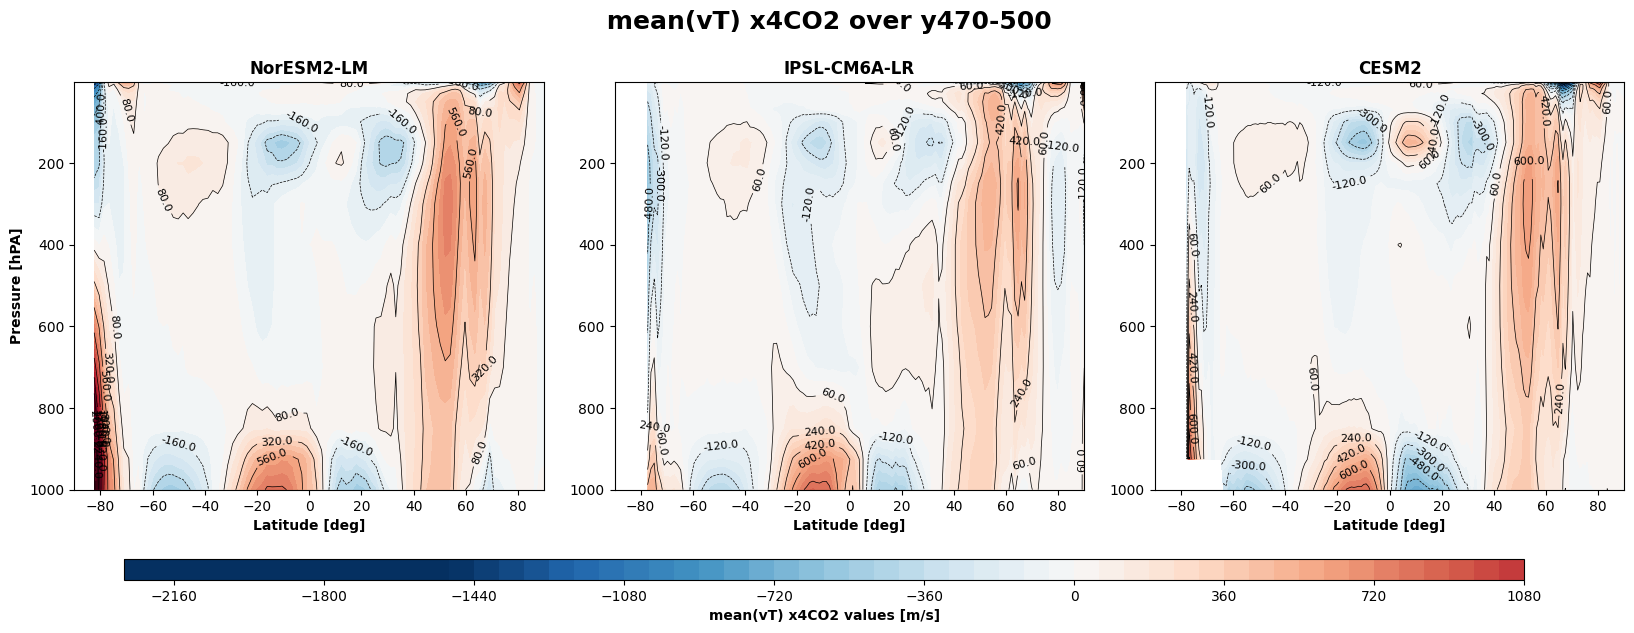

In [37]:
data_piControl_list = [zonal_total_x4_470_500_noresm2, zonal_total_x4_870_900_ipsl, zonal_total_x4_970_999_cesm2]
titles = ["NorESM2-LM", "IPSL-CM6A-LR", "CESM2"]

fig = plt.figure(figsize=(20, 6))
gs = fig.add_gridspec(nrows=1, ncols=3, width_ratios=[1, 1, 1])

# Copy and modify cmap
cmap = plt.get_cmap("coolwarm").copy()
cmap.set_bad(color="white")

for i, data_piControl in enumerate(data_piControl_list):

    if titles[i]== "NorESM2-LM":        

        lat = lat_noresm2
        lev = lev_noresm2/100

    elif titles[i]== "CESM2":        

        lat = lat_cesm2
        lev = lev_cesm2/100

    else:
        lat = lat_ipsl
        lev = lev_ipsl/100
        
    data = data_piControl#.values

    # Plot
    ax = fig.add_subplot(gs[0, i])

    im_pi = ax.contourf(
        lat, lev,
        data,
        levels=60,
        cmap="RdBu_r",
        
    vmin=-1500, vmax=1500)

    levels = im_pi.levels
    neg_levels = levels[levels < 0]
    pos_levels = levels[levels > 0]

    # Negative contours (dashed)
    pi_neg = ax.contour(lat, lev,
        (data),
        levels=neg_levels[::3],
        colors='k',
        linestyles='dashed',
        linewidths=0.5
    )
    
    # Positive contours (solid)
    pi_pos = ax.contour(lat, lev,
        (data),
        levels=pos_levels[::3],
        colors='k',
        linestyles='solid',
        linewidths=0.5
    )
    ax.set_title(titles[i], fontweight='bold')
    ax.invert_yaxis()
    
    if i == 0:
        ax.set_ylabel("Pressure [hPA]", fontweight="bold")

    # Add x-label to all panels
    ax.set_xlabel("Latitude [deg]", fontweight="bold")

    ax.clabel(pi_neg, inline=True, fmt="%1.1f", fontsize=8)
    ax.clabel(pi_pos, inline=True, fmt="%1.1f", fontsize=8)

# ---- Horizontal colorbar spanning all panels ----
cbar_ax = fig.add_axes([0.15, 0.05, 0.7, 0.035])  # [left, bottom, width, height]
cbar = fig.colorbar(im_pi, cax=cbar_ax, orientation="horizontal")
cbar.set_label("mean(vT) x4CO2 values [m/s]", fontweight='bold')

fig.suptitle(" mean(vT) x4CO2 over y470-500", fontsize=18, weight='bold', y=1)
plt.subplots_adjust(top=0.88, bottom=0.20, wspace=0.15)

plt.show()

In [30]:
def nearest_levels(data, target_levels):
    data_vals = np.unique(data[~np.isnan(data)])
    return np.array([
        data_vals[np.argmin(np.abs(data_vals - lvl))]
        for lvl in target_levels
    ])

In [31]:
np.nanmin(zonal_total_x4_470_500_cesm2 - zonal_total_pi_cesm2)

np.float64(-2061.3101284414624)

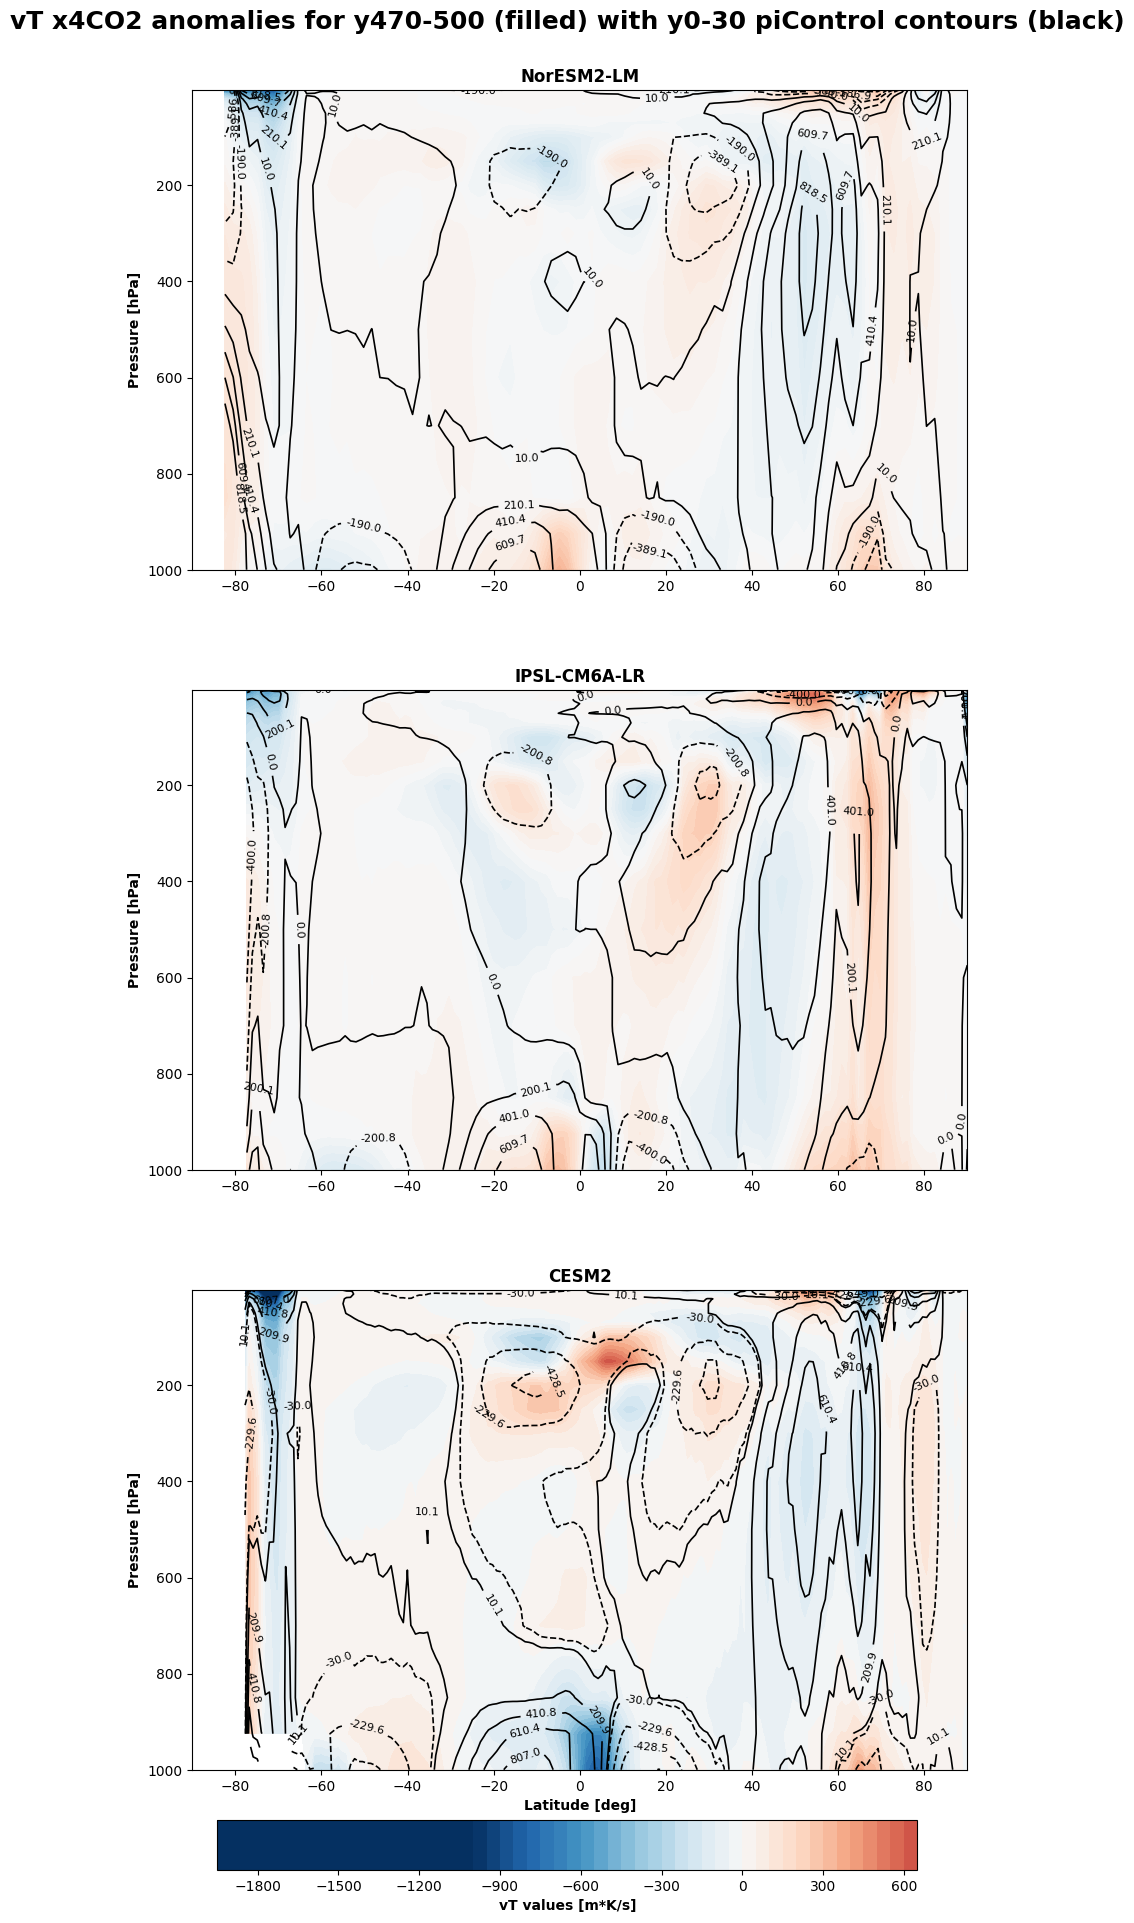

In [58]:
titles = ["NorESM2-LM", "IPSL-CM6A-LR", "CESM2"]

data_piControl_list = [zonal_total_pi_noresm2, zonal_total_pi_ipsl, zonal_total_pi_cesm2]

data_anom_list = [
    (zonal_total_x4_470_500_noresm2 - zonal_total_pi_noresm2),
    (zonal_total_x4_870_900_ipsl - zonal_total_pi_ipsl),
    (zonal_total_x4_970_999_cesm2 - zonal_total_pi_cesm2)
]

fig = plt.figure(figsize=(10, 20))
gs = fig.add_gridspec(nrows=3, ncols=1, height_ratios=[1, 1, 1])

# Copy and modify cmap
cmap = plt.get_cmap("coolwarm").copy()
cmap.set_bad(color="white")

for i in range(3):

    if titles[i]== "NorESM2-LM":        

        lat = lat_noresm2
        lev = lev_noresm2/100

    elif titles[i]== "CESM2":        

        lat = lat_cesm2
        lev = lev_cesm2/100

    else:
        lat = lat_ipsl
        lev = lev_ipsl/100

    data_picontrol = data_piControl_list[i]
    data_anom = data_anom_list[i]

    target_levels_pi = np.arange(-1000, 1000, 10)
    target_levels_anom = np.arange(-1000,1000, 10)

    ax = fig.add_subplot(gs[i, 0])

    levels_pi = np.unique(nearest_levels(data_picontrol, target_levels_pi))
    levels_anom = np.unique(nearest_levels(data_anom, target_levels_anom))
    
    neg_levels_pi = levels_pi[levels_pi < 0]
    pos_levels_pi = levels_pi[levels_pi > 0]

    # ---- Line contours: piControl (grey) ----
    pi_neg = ax.contour(
        lat, lev,
        data_picontrol,
        levels=neg_levels_pi[::20],
        colors="k",
        linestyles="dashed",
        linewidths=1.2
    )

    pi_pos = ax.contour(
        lat, lev,
        data_picontrol,
        levels=pos_levels_pi[::20],
        colors="k",
        linestyles="solid",
        linewidths=1.2
    )

    neg_levels_anom = levels_anom[levels_anom < 0]
    pos_levels_anom = levels_anom[levels_anom > 0]

    # ---- Filled contours: anom ----
    im_anom = ax.contourf(
        lat, lev,
        data_anom,
        levels=60,
        cmap="RdBu_r",
        vmin=-1000, vmax=1000
    )

    # ---- Line contours: anom (black) ----
#    anom_neg = ax.contour(
#        lat, lev,
#        data_anom,
#        levels=neg_levels_anom[::3],
#        colors="k",
#        linestyles="solid",
#        linewidths=1.2
#    )

#    anom_pos = ax.contour(
#        lat, lev,
#        data_anom,
#        levels=pos_levels_anom[::3],
#        colors="k",
#        linestyles="solid",
#        linewidths=1.2
#    )

    ax.set_title(titles[i], fontweight="bold")
    ax.invert_yaxis()

    ax.set_ylabel("Pressure [hPa]", fontweight="bold")

    ax.clabel(pi_neg, inline=True, fmt="%1.1f", fontsize=8)
    ax.clabel(pi_pos, inline=True, fmt="%1.1f", fontsize=8)

#    ax.clabel(anom_neg, inline=True, fmt="%1.1f", fontsize=8)
#    ax.clabel(anom_pos, inline=True, fmt="%1.1f", fontsize=8)

ax.set_xlabel("Latitude [deg]", fontweight="bold")

# ---- Horizontal colorbar ----
cbar_ax = fig.add_axes([0.15, 0.05, 0.7, 0.025])
cbar = fig.colorbar(im_anom, cax=cbar_ax, orientation="horizontal")
cbar.set_label("vT values [m*K/s]", fontweight="bold")

fig.suptitle(
    "vT x4CO2 anomalies for y470-500 (filled) with y0-30 piControl contours (black)",
    fontsize=18,
    weight="bold",
    y=0.98
)

plt.subplots_adjust(top=0.94, bottom=0.10, hspace=0.25)
plt.show()